
# MATISSE 5NF9 — 100 ps replicate analysis + crystallographic ligand volume

This notebook performs the full reviewer-oriented MATISSE analysis and automatically calculates the molecular volume of the removed crystallographic ligand.

## Required inputs

Upload **three files together**:

1. `5NF9_MATISSE_all_replicates.txt`
2. `5NF9_MATISSE_summary.txt`
3. The isolated crystallographic ligand from **Obj 2**, preferably as:
   - `.sdf` **recommended**
   - `.mol`
   - `.mol2`
   - `.pdb`

> SDF/MOL/MOL2 are preferred because bond orders are normally preserved better than in PDB.

## Main MATISSE quantities

\[
V_e = V - V_i
\]

where:

- **V** = summed MATISSE sphere volume
- **Vi** = pairwise sphere-intersection volume
- **Ve** = effective MATISSE pocket volume

## Analyses performed

- input and identity validation: \(V_e = V - V_i\)
- whole-trajectory macro-vs-raw summary validation
- 0–10 ps relaxation region
- 10–100 ps post-relaxation region
- mean, SD, median, min, max and CV for each replicate
- mean \(V\), `stdV`, mean \(V_i\), `stdVi`
- mean \(V_e\), `stdVe`
- 10–40, 40–70 and 70–100 ps block comparison
- 5 ps running average
- mean ± SD across **independent replicate means**
- crystallographic ligand molecular volume
- ligand-to-pocket reference comparison
- reviewer-ready plots
- CSV tables, PNG figures and automatic text report
- ZIP export of all results

### Important interpretation

The hundreds of saved MD frames describe the trajectory distributions and fluctuations, but adjacent frames are temporally correlated. The **independent statistical units are the independent replicate trajectories**, not every saved snapshot.


In [1]:

#@title 1. Analysis settings

RELAX_END_PS = 10.0       #@param {type:"number"}
ANALYSIS_END_PS = 100.0   #@param {type:"number"}
RUNNING_AVG_PS = 5.0      #@param {type:"number"}

BLOCKS = [
    (0.0, 10.0),
    (10.0, 40.0),
    (40.0, 70.0),
    (70.0, 100.0),
]

# RDKit molecular-volume settings.
# 0.20 Å is the primary grid spacing.
LIGAND_GRID_SPACING_A = 0.20   #@param {type:"number"}
LIGAND_BOX_MARGIN_A = 2.0      #@param {type:"number"}

# Also calculate a small grid-spacing sensitivity check.
LIGAND_GRID_SENSITIVITY = [0.10, 0.15, 0.20, 0.25]

FIG_DPI = 300                  #@param {type:"integer"}
OUTPUT_DIR = "MATISSE_analysis_output"

print("Settings loaded")
print(f"Relaxation region: 0–{RELAX_END_PS:g} ps")
print(f"Main analysis region: {RELAX_END_PS:g}–{ANALYSIS_END_PS:g} ps")
print(f"Running-average window: {RUNNING_AVG_PS:g} ps")
print(f"Ligand-volume primary grid spacing: {LIGAND_GRID_SPACING_A:g} Å")


Settings loaded
Relaxation region: 0–10 ps
Main analysis region: 10–100 ps
Running-average window: 5 ps
Ligand-volume primary grid spacing: 0.2 Å


In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 46.2 MB/s eta 0:00:00


In [3]:

#@title 2. Install/import required packages

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("rdkit") is None:
    print("RDKit is not available; installing it...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rdkit"])

from google.colab import files
import io
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

print("Packages ready.")


Packages ready.


In [4]:

#@title 3. Upload the two MATISSE text files + isolated ligand structure

uploaded = files.upload()

if len(uploaded) < 3:
    raise RuntimeError(
        "Please upload THREE files together:\n"
        "1) 5NF9_MATISSE_all_replicates.txt\n"
        "2) 5NF9_MATISSE_summary.txt\n"
        "3) isolated crystallographic ligand (.sdf/.mol/.mol2/.pdb)"
    )

def find_uploaded_file(keyword):
    matches = [name for name in uploaded if keyword.lower() in name.lower()]
    return matches[0] if matches else None

raw_name = find_uploaded_file("all_replicates")
summary_name = find_uploaded_file("summary")

structure_exts = {".sdf", ".mol", ".mol2", ".pdb"}
ligand_candidates = [
    name for name in uploaded
    if Path(name).suffix.lower() in structure_exts
    and name not in {raw_name, summary_name}
]

if raw_name is None:
    raise RuntimeError("Could not identify the MATISSE file containing 'all_replicates'.")
if summary_name is None:
    raise RuntimeError("Could not identify the MATISSE file containing 'summary'.")
if len(ligand_candidates) == 0:
    raise RuntimeError(
        "No ligand structure was detected. Upload isolated Obj 2 as SDF, MOL, MOL2 or PDB."
    )

if len(ligand_candidates) > 1:
    print("Multiple ligand-like structure files detected:")
    for x in ligand_candidates:
        print(" -", x)
    print("Using the first one. Remove extra structure files if this is not intended.")

ligand_name = ligand_candidates[0]

print("Raw MATISSE file:", raw_name)
print("Summary file:", summary_name)
print("Ligand structure:", ligand_name)


Saving 5nf9_lig.pdb to 5nf9_lig.pdb
Saving 5NF9_MATISSE_all_replicates.txt to 5NF9_MATISSE_all_replicates.txt
Saving 5NF9_MATISSE_summary.txt to 5NF9_MATISSE_summary.txt
Raw MATISSE file: 5NF9_MATISSE_all_replicates.txt
Summary file: 5NF9_MATISSE_summary.txt
Ligand structure: 5nf9_lig.pdb


In [5]:

#@title 4. Read and normalize the MATISSE tables

def read_whitespace_table(file_bytes):
    return pd.read_csv(io.BytesIO(file_bytes), sep=r"\s+", engine="python")

raw_original = read_whitespace_table(uploaded[raw_name])
summary_original = read_whitespace_table(uploaded[summary_name])

RAW_ALIASES = {
    "Replicate": "Rep",
    "Rep": "Rep",
    "Seed": "Seed",
    "Snapshot": "Snap",
    "Snap": "Snap",
    "Time_fs": "Time_fs",
    "Time_ps": "Time_ps",
    "LocalWaters": "LocalW",
    "LocalW": "LocalW",
    "MATISSESpheres": "Spheres",
    "Spheres": "Spheres",
    "MotherSphereVolume_A3": "V",
    "V": "V",
    "MotherOverlap_A3": "Vi",
    "Vi": "Vi",
    "EffectiveVolume_A3": "Ve",
    "Ve": "Ve",
}

SUMMARY_ALIASES = {
    "Replicate": "Rep",
    "Rep": "Rep",
    "Seed": "Seed",
    "MeanVe_A3": "Ve",
    "SDVe_A3": "stdVe",
    "MinVe_A3": "minVe",
    "MaxVe_A3": "maxVe",
    "V": "V",
    "stdV": "stdV",
    "Vi": "Vi",
    "stdVi": "stdVi",
    "Ve": "Ve",
    "stdVe": "stdVe",
}

raw = raw_original.rename(
    columns={c: RAW_ALIASES.get(c, c) for c in raw_original.columns}
).copy()

summary = summary_original.rename(
    columns={c: SUMMARY_ALIASES.get(c, c) for c in summary_original.columns}
).copy()

required_raw = ["Rep", "Seed", "Snap", "Time_fs", "Time_ps", "V", "Vi", "Ve"]
missing = [c for c in required_raw if c not in raw.columns]
if missing:
    raise RuntimeError(
        "Raw MATISSE file is missing required columns: " + ", ".join(missing)
    )

for col in raw.columns:
    raw[col] = pd.to_numeric(raw[col], errors="ignore")
for col in summary.columns:
    summary[col] = pd.to_numeric(summary[col], errors="ignore")

raw["Rep"] = raw["Rep"].astype(int)
raw["Snap"] = raw["Snap"].astype(int)

if "Rep" in summary.columns:
    summary["Rep"] = summary["Rep"].astype(int)

raw = raw.sort_values(["Rep", "Time_ps", "Snap"]).reset_index(drop=True)

rep_ids = sorted(raw["Rep"].unique().tolist())

print("Replicates detected:", rep_ids)
print("Number of independent trajectories:", len(rep_ids))
print(f"Observed time range: {raw['Time_ps'].min():.4f}–{raw['Time_ps'].max():.4f} ps")
print("Total frames:", len(raw))

display(raw.head())
display(summary)


Replicates detected: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of independent trajectories: 10
Observed time range: 0.0000–100.0000 ps
Total frames: 1210


/tmp/ipykernel_3531/630053690.py:61: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  raw[col] = pd.to_numeric(raw[col], errors="ignore")
/tmp/ipykernel_3531/630053690.py:63: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  summary[col] = pd.to_numeric(summary[col], errors="ignore")


,Rep,Seed,Snap,Time_fs,Time_ps,LocalW,Spheres,V,Vi,Ve
0,1,20260812.0,0,0.0,0.0000,16.0,8.0,1175.0,292.0,883.0
1,1,20260812.0,1,832.5,0.8325,16.0,11.0,1374.0,460.0,914.0
2,1,20260812.0,2,1665.0,1.6650,16.0,14.0,1841.0,961.0,880.0
3,1,20260812.0,3,2497.5,2.4975,16.0,14.0,1667.0,646.0,1021.0
4,1,20260812.0,4,3330.0,3.3300,16.0,13.0,941.0,221.0,720.0


,Rep,Seed,V,stdV,Vi,stdVi,Ve,stdVe
0,1,20260812.0,1199.8017,296.1470,191.4215,129.3709,1008.3802,238.8468
1,2,20260813.0,884.3388,305.5938,133.6612,104.8726,750.6777,258.9489
2,3,20260814.0,774.4298,253.9099,23.1074,45.6771,751.3223,233.7764
3,4,20260815.0,728.0413,281.1004,58.3223,103.9293,669.7190,244.2945
4,5,20260816.0,839.2231,237.7853,51.5124,50.3571,787.7107,215.0259
5,6,20260817.0,874.4132,222.0098,49.2231,76.4452,825.1901,207.1666
6,7,20260818.0,922.7438,274.2511,66.6116,75.1739,856.1322,230.2942
7,8,20260819.0,1227.6694,322.6540,190.4050,167.4166,1037.2645,229.2022
8,9,20260820.0,1091.1157,250.2236,111.5041,125.0322,979.6116,229.5512
9,10,20260821.0,773.4545,271.3859,31.4793,61.5222,741.9752,241.7985


In [6]:

#@title 5. Load the crystallographic ligand and calculate its molecular volume

ligand_path = Path("/content") / ligand_name
ligand_path.write_bytes(uploaded[ligand_name])

ext = ligand_path.suffix.lower()

def load_ligand(path):
    ext = path.suffix.lower()

    if ext == ".sdf":
        supplier = Chem.SDMolSupplier(str(path), removeHs=False, sanitize=True)
        mols = [m for m in supplier if m is not None]
        return mols[0] if mols else None

    if ext == ".mol":
        return Chem.MolFromMolFile(str(path), removeHs=False, sanitize=True)

    if ext == ".mol2":
        return Chem.MolFromMol2File(str(path), removeHs=False, sanitize=True)

    if ext == ".pdb":
        # PDB is supported, but SDF/MOL/MOL2 is preferable for ligand chemistry.
        mol = Chem.MolFromPDBFile(
            str(path),
            sanitize=True,
            removeHs=False,
            proximityBonding=True
        )
        if mol is None:
            warnings.warn(
                "Sanitized PDB loading failed. Retrying without sanitization. "
                "Prefer SDF/MOL2 if possible."
            )
            mol = Chem.MolFromPDBFile(
                str(path),
                sanitize=False,
                removeHs=False,
                proximityBonding=True
            )
        return mol

    return None

ligand = load_ligand(ligand_path)

if ligand is None:
    raise RuntimeError(
        "RDKit could not read the ligand. Export Obj 2 as SDF if possible and retry."
    )

if ligand.GetNumConformers() == 0:
    raise RuntimeError(
        "The ligand file has no 3D coordinates. Export the crystallographic Obj 2 "
        "with its original 3D coordinates."
    )

# Preserve crystallographic heavy-atom coordinates and add H atoms only if absent.
nH_input = sum(1 for a in ligand.GetAtoms() if a.GetAtomicNum() == 1)
ligand_for_volume = Chem.Mol(ligand)
hydrogen_note = ""

if nH_input == 0:
    try:
        ligand_for_volume = Chem.AddHs(ligand_for_volume, addCoords=True)
        hydrogen_note = "Hydrogens were added by RDKit while preserving the input heavy-atom conformation."
    except Exception as e:
        warnings.warn(
            "RDKit could not add hydrogens. Molecular volume will be calculated "
            "from the atoms present in the input structure."
        )
        ligand_for_volume = Chem.Mol(ligand)
        hydrogen_note = "Hydrogen addition failed; input atoms were used as supplied."
else:
    hydrogen_note = "Explicit hydrogens present in the input ligand were retained."

# Primary ligand volume.
ligand_volume_A3 = float(
    AllChem.ComputeMolVolume(
        ligand_for_volume,
        confId=-1,
        gridSpacing=float(LIGAND_GRID_SPACING_A),
        boxMargin=float(LIGAND_BOX_MARGIN_A)
    )
)

# Small grid-spacing sensitivity check.
ligand_volume_sensitivity_rows = []
for spacing in LIGAND_GRID_SENSITIVITY:
    vol = float(
        AllChem.ComputeMolVolume(
            ligand_for_volume,
            confId=-1,
            gridSpacing=float(spacing),
            boxMargin=float(LIGAND_BOX_MARGIN_A)
        )
    )
    ligand_volume_sensitivity_rows.append(
        {"gridSpacing_A": spacing, "LigandVolume_A3": vol}
    )

ligand_volume_sensitivity = pd.DataFrame(ligand_volume_sensitivity_rows)

ligand_info = pd.DataFrame({
    "Property": [
        "Ligand file",
        "Input format",
        "Atoms in input",
        "Explicit H in input",
        "Atoms used for volume",
        "Molecular weight",
        "Primary grid spacing (A)",
        "Box margin (A)",
        "Ligand molecular volume (A3)",
        "Hydrogen handling",
    ],
    "Value": [
        ligand_name,
        ext,
        ligand.GetNumAtoms(),
        nH_input,
        ligand_for_volume.GetNumAtoms(),
        f"{Descriptors.MolWt(ligand_for_volume):.4f}",
        LIGAND_GRID_SPACING_A,
        LIGAND_BOX_MARGIN_A,
        f"{ligand_volume_A3:.4f}",
        hydrogen_note,
    ]
})

print(f"Ligand molecular volume = {ligand_volume_A3:.3f} Å³")
print(hydrogen_note)
print("\nLigand information:")
display(ligand_info)

print("\nGrid-spacing sensitivity:")
display(ligand_volume_sensitivity)


Ligand molecular volume = 449.840 Å³
Explicit hydrogens present in the input ligand were retained.

Ligand information:


,Property,Value
0,Ligand file,5nf9_lig.pdb
1,Input format,.pdb
2,Atoms in input,68
3,Explicit H in input,32
4,Atoms used for volume,68
5,Molecular weight,526.5800
6,Primary grid spacing (A),0.2
7,Box margin (A),2.0
8,Ligand molecular volume (A3),449.8400
9,Hydrogen handling,Explicit hydrogens present in the input ligand...



Grid-spacing sensitivity:


,gridSpacing_A,LigandVolume_A3
0,0.10,449.919000
1,0.15,449.863875
2,0.20,449.840000
3,0.25,449.718750



### Ligand-volume method

The ligand reference is the volume of the **uploaded crystallographic conformer**, not the volume of a newly optimized ligand.

The calculation uses RDKit `ComputeMolVolume`, which represents the conformer on a 3D grid. The primary value uses the grid spacing selected above (default 0.20 Å). A small grid-spacing sensitivity table is also produced.

The ligand volume is used only as a **physical reference scale**. It is not expected to equal \(V_e\), because the MATISSE pocket is a water-accessible cavity representation rather than the geometric volume of the bound ligand itself.


In [7]:

#@title 6. Validate Ve = V - Vi and compare macro summary with raw data

raw["Ve_from_V_minus_Vi"] = raw["V"] - raw["Vi"]
raw["Ve_abs_error"] = (raw["Ve"] - raw["Ve_from_V_minus_Vi"]).abs()

max_identity_error = float(raw["Ve_abs_error"].max())

whole_summary = (
    raw.groupby("Rep", as_index=False)
       .agg(
           V=("V", "mean"),
           stdV=("V", "std"),
           Vi=("Vi", "mean"),
           stdVi=("Vi", "std"),
           Ve=("Ve", "mean"),
           stdVe=("Ve", "std"),
           minVe=("Ve", "min"),
           maxVe=("Ve", "max"),
           nFrames=("Ve", "size"),
       )
)

macro_cols = [
    c for c in
    ["Rep", "V", "stdV", "Vi", "stdVi", "Ve", "stdVe", "minVe", "maxVe"]
    if c in summary.columns
]

if "Rep" in macro_cols and len(macro_cols) > 1:
    macro_check = whole_summary.merge(
        summary[macro_cols],
        on="Rep",
        how="left",
        suffixes=("_recalc", "_macro")
    )
else:
    macro_check = whole_summary.copy()

print(f"Maximum |Ve - (V - Vi)| = {max_identity_error:.8f} Å³")

if max_identity_error > 1e-3:
    warnings.warn("Ve does not equal V - Vi for one or more frames.")

print("\nWhole-trajectory statistics recalculated from raw data:")
display(whole_summary)

print("\nMacro summary versus recalculated summary:")
display(macro_check)


Maximum |Ve - (V - Vi)| = 0.00000000 Å³

Whole-trajectory statistics recalculated from raw data:


,Rep,V,stdV,Vi,stdVi,Ve,stdVe,minVe,maxVe,nFrames
0,1,1199.801653,297.378368,191.421488,129.908798,1008.380165,239.839886,549.0,1679.0,121
1,2,884.338843,306.864453,133.661157,105.308638,750.677686,260.025615,361.0,1888.0,121
2,3,774.429752,254.965711,23.107438,45.866982,751.322314,234.748490,174.0,1300.0,121
3,4,728.041322,282.269239,58.322314,104.361408,669.719008,245.310321,129.0,1351.0,121
4,5,839.223140,238.774004,51.512397,50.566477,787.710744,215.919948,364.0,1346.0,121
5,6,874.413223,222.932900,49.223140,76.763108,825.190083,208.027975,250.0,1328.0,121
6,7,922.743802,275.391465,66.611570,75.486464,856.132231,231.251809,436.0,1354.0,121
7,8,1227.669421,323.995586,190.404959,168.112739,1037.264463,230.155265,296.0,1494.0,121
8,9,1091.115702,251.264044,111.504132,125.552056,979.611570,230.505689,481.0,1553.0,121
9,10,773.454545,272.514312,31.479339,61.777976,741.975207,242.803949,255.0,1494.0,121



Macro summary versus recalculated summary:


,Rep,V_recalc,stdV_recalc,Vi_recalc,stdVi_recalc,Ve_recalc,stdVe_recalc,minVe,maxVe,nFrames,V_macro,stdV_macro,Vi_macro,stdVi_macro,Ve_macro,stdVe_macro
0,1,1199.801653,297.378368,191.421488,129.908798,1008.380165,239.839886,549.0,1679.0,121,1199.8017,296.1470,191.4215,129.3709,1008.3802,238.8468
1,2,884.338843,306.864453,133.661157,105.308638,750.677686,260.025615,361.0,1888.0,121,884.3388,305.5938,133.6612,104.8726,750.6777,258.9489
2,3,774.429752,254.965711,23.107438,45.866982,751.322314,234.748490,174.0,1300.0,121,774.4298,253.9099,23.1074,45.6771,751.3223,233.7764
3,4,728.041322,282.269239,58.322314,104.361408,669.719008,245.310321,129.0,1351.0,121,728.0413,281.1004,58.3223,103.9293,669.7190,244.2945
4,5,839.223140,238.774004,51.512397,50.566477,787.710744,215.919948,364.0,1346.0,121,839.2231,237.7853,51.5124,50.3571,787.7107,215.0259
5,6,874.413223,222.932900,49.223140,76.763108,825.190083,208.027975,250.0,1328.0,121,874.4132,222.0098,49.2231,76.4452,825.1901,207.1666
6,7,922.743802,275.391465,66.611570,75.486464,856.132231,231.251809,436.0,1354.0,121,922.7438,274.2511,66.6116,75.1739,856.1322,230.2942
7,8,1227.669421,323.995586,190.404959,168.112739,1037.264463,230.155265,296.0,1494.0,121,1227.6694,322.6540,190.4050,167.4166,1037.2645,229.2022
8,9,1091.115702,251.264044,111.504132,125.552056,979.611570,230.505689,481.0,1553.0,121,1091.1157,250.2236,111.5041,125.0322,979.6116,229.5512
9,10,773.454545,272.514312,31.479339,61.777976,741.975207,242.803949,255.0,1494.0,121,773.4545,271.3859,31.4793,61.5222,741.9752,241.7985


In [8]:

#@title 7. Sampling diagnostics and requested time-window checks

sampling_rows = []

for rep, grp in raw.groupby("Rep"):
    times = np.sort(grp["Time_ps"].unique())
    diffs = np.diff(times)
    diffs = diffs[diffs > 0]

    sampling_rows.append({
        "Rep": rep,
        "nFrames": len(grp),
        "Start_ps": grp["Time_ps"].min(),
        "End_ps": grp["Time_ps"].max(),
        "MedianSamplingInterval_ps": np.median(diffs) if len(diffs) else np.nan,
        "MinSamplingInterval_ps": np.min(diffs) if len(diffs) else np.nan,
        "MaxSamplingInterval_ps": np.max(diffs) if len(diffs) else np.nan,
    })

sampling_diagnostics = pd.DataFrame(sampling_rows)

display(sampling_diagnostics)

if raw["Time_ps"].max() < RELAX_END_PS:
    warnings.warn(
        f"Dataset ends before the {RELAX_END_PS:g} ps relaxation boundary."
    )
elif raw["Time_ps"].max() < ANALYSIS_END_PS:
    warnings.warn(
        f"Dataset ends before the requested {ANALYSIS_END_PS:g} ps endpoint."
    )


,Rep,nFrames,Start_ps,End_ps,MedianSamplingInterval_ps,MinSamplingInterval_ps,MaxSamplingInterval_ps
0,1,121,0.0,100.0,0.8325,0.1,1.665
1,2,121,0.0,100.0,0.8325,0.1,1.665
2,3,121,0.0,100.0,0.8325,0.1,1.665
3,4,121,0.0,100.0,0.8325,0.1,1.665
4,5,121,0.0,100.0,0.8325,0.1,1.665
5,6,121,0.0,100.0,0.8325,0.1,1.665
6,7,121,0.0,100.0,0.8325,0.1,1.665
7,8,121,0.0,100.0,0.8325,0.1,1.665
8,9,121,0.0,100.0,0.8325,0.1,1.665
9,10,121,0.0,100.0,0.8325,0.1,1.665


In [9]:

#@title 8. Define relaxation and post-relaxation datasets

# Non-overlapping convention:
# relaxation:    0 <= t < 10 ps
# analysis:     10 <= t <= 100 ps

relax = raw[
    (raw["Time_ps"] >= 0.0) &
    (raw["Time_ps"] < RELAX_END_PS)
].copy()

analysis = raw[
    (raw["Time_ps"] >= RELAX_END_PS) &
    (raw["Time_ps"] <= ANALYSIS_END_PS)
].copy()

print(f"Relaxation frames: {len(relax)}")
print(f"Post-relaxation frames: {len(analysis)}")

if analysis.empty:
    warnings.warn(
        "No frames are present in the requested post-relaxation interval."
    )


Relaxation frames: 130
Post-relaxation frames: 1080


In [10]:

#@title 9. Per-replicate reviewer statistics

def cv_percent(series):
    m = series.mean()
    if pd.isna(m) or m == 0:
        return np.nan
    return series.std(ddof=1) / m * 100.0

early_means = (
    relax.groupby("Rep")["Ve"].mean()
    if not relax.empty else pd.Series(dtype=float)
)

if not analysis.empty:
    per_rep = (
        analysis.groupby("Rep")
        .agg(
            nFrames=("Ve", "size"),
            meanV=("V", "mean"),
            stdV=("V", "std"),
            meanVi=("Vi", "mean"),
            stdVi=("Vi", "std"),
            meanVe=("Ve", "mean"),
            stdVe=("Ve", "std"),
            medianVe=("Ve", "median"),
            minVe=("Ve", "min"),
            maxVe=("Ve", "max"),
        )
        .reset_index()
    )

    cvs = (
        analysis.groupby("Rep")["Ve"]
        .apply(cv_percent)
        .rename("CV_percent")
        .reset_index()
    )

    per_rep = per_rep.merge(cvs, on="Rep", how="left")

else:
    per_rep = pd.DataFrame({"Rep": rep_ids})

per_rep["meanVe_0_10ps"] = per_rep["Rep"].map(early_means)

if "meanVe" in per_rep.columns:
    per_rep["meanVe_10_100ps"] = per_rep["meanVe"]
    per_rep["delta_post_minus_early"] = (
        per_rep["meanVe_10_100ps"] - per_rep["meanVe_0_10ps"]
    )
    per_rep["percent_change_early_to_post"] = (
        per_rep["delta_post_minus_early"] /
        per_rep["meanVe_0_10ps"] * 100.0
    )

display(per_rep)


,Rep,nFrames,meanV,stdV,meanVi,stdVi,meanVe,stdVe,medianVe,minVe,maxVe,CV_percent,meanVe_0_10ps,meanVe_10_100ps,delta_post_minus_early,percent_change_early_to_post
0,1,108,1187.796296,302.296066,170.500000,97.829768,1017.296296,250.091320,1014.0,549.0,1679.0,24.583921,934.307692,1017.296296,82.988604,8.882363
1,2,108,857.990741,307.167722,111.018519,72.148080,746.972222,272.623785,685.0,361.0,1888.0,36.497178,781.461538,746.972222,-34.489316,-4.413437
2,3,108,750.990741,251.696245,12.768519,20.203454,738.222222,240.730211,749.5,174.0,1300.0,32.609451,860.153846,738.222222,-121.931624,-14.175560
3,4,108,721.527778,275.159035,40.000000,54.854438,681.527778,251.057184,700.0,129.0,1351.0,36.837410,571.615385,681.527778,109.912393,19.228383
4,5,108,849.574074,227.920063,44.944444,39.357179,804.629630,207.618836,793.5,370.0,1346.0,25.803031,647.153846,804.629630,157.475783,24.333593
5,6,108,860.416667,218.624208,31.333333,48.845360,829.083333,212.160807,862.5,250.0,1328.0,25.589805,792.846154,829.083333,36.237179,4.570518
6,7,108,884.981481,261.364070,47.111111,45.316815,837.870370,232.855982,818.0,436.0,1354.0,27.791409,1007.846154,837.870370,-169.975783,-16.865251
7,8,108,1222.342593,328.994451,171.157407,158.242046,1051.185185,229.259440,1072.0,296.0,1494.0,21.809615,921.615385,1051.185185,129.569801,14.058988
8,9,108,1084.898148,249.192863,80.611111,72.724526,1004.287037,226.895219,1003.5,481.0,1553.0,22.592666,774.615385,1004.287037,229.671652,29.649766
9,10,108,736.037037,254.080123,20.074074,32.970591,715.962963,239.565063,692.0,255.0,1494.0,33.460538,958.076923,715.962963,-242.113960,-25.270827


In [11]:

#@title 10. Combined result across independent replicate means

if not analysis.empty and "meanVe" in per_rep.columns:
    replicate_means = per_rep["meanVe"].dropna()

    combined_mean_Ve = float(replicate_means.mean())
    combined_sd_Ve = float(replicate_means.std(ddof=1))

    combined = pd.DataFrame({
        "Metric": [
            "Mean of replicate mean Ve",
            "SD between replicate mean Ve",
            "Minimum replicate mean Ve",
            "Maximum replicate mean Ve",
            "Number of independent replicates",
            "Mean within-replicate stdVe",
        ],
        "Value": [
            combined_mean_Ve,
            combined_sd_Ve,
            replicate_means.min(),
            replicate_means.max(),
            len(replicate_means),
            per_rep["stdVe"].mean(),
        ]
    })

    print(
        f"Post-relaxation Ve = {combined_mean_Ve:.3f} ± "
        f"{combined_sd_Ve:.3f} Å³ "
        f"(mean ± SD across {len(replicate_means)} independent replicate means)"
    )

    display(combined)
else:
    combined_mean_Ve = np.nan
    combined_sd_Ve = np.nan
    combined = pd.DataFrame(columns=["Metric", "Value"])
    print("Combined post-relaxation statistics are unavailable.")


Post-relaxation Ve = 842.704 ± 134.922 Å³ (mean ± SD across 10 independent replicate means)


,Metric,Value
0,Mean of replicate mean Ve,842.703704
1,SD between replicate mean Ve,134.922437
2,Minimum replicate mean Ve,681.527778
3,Maximum replicate mean Ve,1051.185185
4,Number of independent replicates,10.000000
5,Mean within-replicate stdVe,236.285784


In [12]:

#@title 11. Ligand versus post-relaxation pocket-volume reference

if not np.isnan(combined_mean_Ve):
    ligand_comparison = pd.DataFrame({
        "Quantity": [
            "Crystallographic ligand volume",
            "Post-relaxation mean Ve",
            "SD between replicate mean Ve",
            "Ve - ligand volume",
            "Ve / ligand volume",
            "Ligand volume / Ve (%)",
        ],
        "Value": [
            ligand_volume_A3,
            combined_mean_Ve,
            combined_sd_Ve,
            combined_mean_Ve - ligand_volume_A3,
            combined_mean_Ve / ligand_volume_A3,
            ligand_volume_A3 / combined_mean_Ve * 100.0,
        ],
        "Unit_or_interpretation": [
            "Å³",
            "Å³",
            "Å³",
            "Å³",
            "dimensionless size ratio",
            "size-reference percentage; NOT an occupancy estimate",
        ]
    })

    print("Ligand-to-pocket reference comparison:")
    display(ligand_comparison)

    print(
        f"\nReference statement:\n"
        f"The crystallographic ligand molecular volume was "
        f"{ligand_volume_A3:.1f} Å³, whereas the post-relaxation "
        f"MATISSE-derived effective pocket volume was "
        f"{combined_mean_Ve:.1f} ± {combined_sd_Ve:.1f} Å³ "
        f"(mean ± SD across independent replicate means)."
    )
else:
    ligand_comparison = pd.DataFrame()


Ligand-to-pocket reference comparison:


,Quantity,Value,Unit_or_interpretation
0,Crystallographic ligand volume,449.840000,Å³
1,Post-relaxation mean Ve,842.703704,Å³
2,SD between replicate mean Ve,134.922437,Å³
3,Ve - ligand volume,392.863704,Å³
4,Ve / ligand volume,1.873341,dimensionless size ratio
5,Ligand volume / Ve (%),53.380565,size-reference percentage; NOT an occupancy es...



Reference statement:
The crystallographic ligand molecular volume was 449.8 Å³, whereas the post-relaxation MATISSE-derived effective pocket volume was 842.7 ± 134.9 Å³ (mean ± SD across independent replicate means).


In [13]:

#@title 12. Block analysis: 0–10, 10–40, 40–70, 70–100 ps

block_rows = []

for rep in rep_ids:
    rep_df = raw[raw["Rep"] == rep]

    for block_index, (start, end) in enumerate(BLOCKS):
        is_last = block_index == len(BLOCKS) - 1

        if is_last:
            subset = rep_df[
                (rep_df["Time_ps"] >= start) &
                (rep_df["Time_ps"] <= end)
            ]
        else:
            subset = rep_df[
                (rep_df["Time_ps"] >= start) &
                (rep_df["Time_ps"] < end)
            ]

        if len(subset):
            block_rows.append({
                "Rep": rep,
                "Block": f"{start:g}-{end:g} ps",
                "Start_ps": start,
                "End_ps": end,
                "nFrames": len(subset),
                "meanV": subset["V"].mean(),
                "stdV": subset["V"].std(ddof=1),
                "meanVi": subset["Vi"].mean(),
                "stdVi": subset["Vi"].std(ddof=1),
                "meanVe": subset["Ve"].mean(),
                "stdVe": subset["Ve"].std(ddof=1),
                "medianVe": subset["Ve"].median(),
                "minVe": subset["Ve"].min(),
                "maxVe": subset["Ve"].max(),
            })

block_stats = pd.DataFrame(block_rows)

if not block_stats.empty:
    block_across_reps = (
        block_stats.groupby(["Block", "Start_ps", "End_ps"], as_index=False)
        .agg(
            mean_of_rep_means=("meanVe", "mean"),
            SD_between_rep_means=("meanVe", "std"),
            nReplicates=("Rep", "nunique"),
        )
        .sort_values("Start_ps")
    )

    print("Per-replicate block statistics:")
    display(block_stats)

    print("\nBlock means across independent replicate means:")
    display(block_across_reps)

    post_blocks = block_across_reps[
        block_across_reps["Start_ps"] >= RELAX_END_PS
    ].copy()

    if len(post_blocks) >= 2:
        post_block_range = (
            post_blocks["mean_of_rep_means"].max() -
            post_blocks["mean_of_rep_means"].min()
        )
        post_block_mean = post_blocks["mean_of_rep_means"].mean()
        post_block_range_percent = (
            post_block_range / post_block_mean * 100.0
        )

        print(
            f"\nPost-relaxation ensemble block-mean range = "
            f"{post_block_range:.3f} Å³ "
            f"({post_block_range_percent:.2f}% of their mean)."
        )
    else:
        post_block_range = np.nan
        post_block_range_percent = np.nan
else:
    block_across_reps = pd.DataFrame()
    post_block_range = np.nan
    post_block_range_percent = np.nan


Per-replicate block statistics:


,Rep,Block,Start_ps,End_ps,nFrames,meanV,stdV,meanVi,stdVi,meanVe,stdVe,medianVe,minVe,maxVe
0,1,0-10 ps,0.0,10.0,13,1299.538462,239.654827,365.230769,216.236041,934.307692,104.275584,914.0,720.0,1141.0
1,1,10-40 ps,10.0,40.0,36,1192.222222,258.569925,219.916667,105.639109,972.305556,174.776890,978.0,667.0,1291.0
2,1,40-70 ps,40.0,70.0,36,1335.861111,283.018238,157.277778,66.738556,1178.583333,255.839054,1125.5,728.0,1679.0
3,1,70-100 ps,70.0,100.0,36,1035.305556,293.130280,134.305556,98.011025,901.000000,229.042479,888.5,549.0,1449.0
4,2,0-10 ps,0.0,10.0,13,1103.230769,205.421580,321.769231,146.755553,781.461538,110.738894,749.0,639.0,1005.0
5,2,10-40 ps,10.0,40.0,36,759.000000,175.578066,120.305556,58.462110,638.694444,133.384261,601.0,428.0,1043.0
6,2,40-70 ps,40.0,70.0,36,684.333333,198.801265,61.250000,39.456576,623.083333,177.253874,564.0,361.0,1110.0
7,2,70-100 ps,70.0,100.0,36,1130.638889,317.079454,151.500000,81.344242,979.138889,307.766995,945.5,519.0,1888.0
8,3,0-10 ps,0.0,10.0,13,969.153846,197.923321,109.000000,91.890333,860.153846,141.289211,874.0,664.0,1074.0
9,3,10-40 ps,10.0,40.0,36,901.361111,205.739385,25.222222,26.446832,876.138889,188.925556,856.0,569.0,1239.0



Block means across independent replicate means:


,Block,Start_ps,End_ps,mean_of_rep_means,SD_between_rep_means,nReplicates
0,0-10 ps,0.0,10.0,824.969231,139.428104,10
1,10-40 ps,10.0,40.0,851.897222,128.317539,10
2,40-70 ps,40.0,70.0,837.730556,212.003748,10
3,70-100 ps,70.0,100.0,838.483333,155.157200,10



Post-relaxation ensemble block-mean range = 14.167 Å³ (1.68% of their mean).


In [14]:

#@title 13. Calculate the 5 ps running average

raw_with_runavg = raw.copy()
raw_with_runavg["Ve_runavg"] = np.nan

running_window_info = []

for rep in rep_ids:
    idx = raw_with_runavg.index[raw_with_runavg["Rep"] == rep]
    rep_df = raw_with_runavg.loc[idx].sort_values("Time_ps")

    dt_values = rep_df["Time_ps"].diff().dropna()
    dt_values = dt_values[dt_values > 0]

    if len(dt_values) == 0:
        continue

    dt = float(dt_values.median())
    frames = max(1, int(round(RUNNING_AVG_PS / dt)))

    if rep_df["Time_ps"].max() - rep_df["Time_ps"].min() < RUNNING_AVG_PS:
        running_window_info.append((rep, dt, frames, False))
        continue

    runavg = (
        rep_df["Ve"]
        .rolling(
            window=frames,
            center=True,
            min_periods=max(2, frames // 2)
        )
        .mean()
    )

    raw_with_runavg.loc[rep_df.index, "Ve_runavg"] = runavg.values
    running_window_info.append((rep, dt, frames, True))

for rep, dt, frames, done in running_window_info:
    print(
        f"Rep {rep}: median Δt={dt:.4g} ps; "
        f"{RUNNING_AVG_PS:g} ps ≈ {frames} frames; "
        f"{'calculated' if done else 'skipped'}"
    )


Rep 1: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 2: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 3: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 4: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 5: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 6: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 7: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 8: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 9: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated
Rep 10: median Δt=0.8325 ps; 5 ps ≈ 6 frames; calculated


In [15]:

#@title 14. Create output directory

outdir = Path(OUTPUT_DIR)
outdir.mkdir(parents=True, exist_ok=True)

print("Output directory:", outdir.resolve())


Output directory: /content/MATISSE_analysis_output


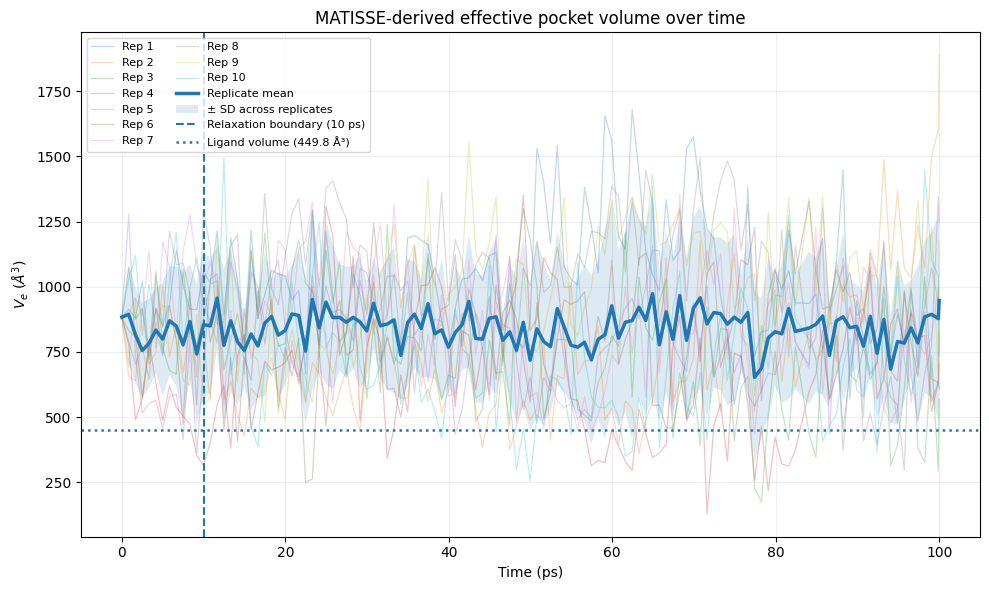

Saved: MATISSE_analysis_output/Figure_A_Ve_time_series_with_ligand_reference.png


In [19]:

#@title 15. Figure A — Ve vs time + replicate mean ± SD + ligand reference

fig, ax = plt.subplots(figsize=(10, 6))

for rep, grp in raw.groupby("Rep"):
    ax.plot(
        grp["Time_ps"],
        grp["Ve"],
        linewidth=0.9,
        alpha=0.28,
        label=f"Rep {rep}"
    )

time_stats = (
    raw.groupby("Time_ps")["Ve"]
       .agg(["mean", "std"])
       .reset_index()
)

ax.plot(
    time_stats["Time_ps"],
    time_stats["mean"],
    linewidth=2.5,
    label="Replicate mean"
)

ax.fill_between(
    time_stats["Time_ps"],
    time_stats["mean"] - time_stats["std"].fillna(0),
    time_stats["mean"] + time_stats["std"].fillna(0),
    alpha=0.15,
    label="± SD across replicates"
)

if raw["Time_ps"].max() >= RELAX_END_PS:
    ax.axvline(
        RELAX_END_PS,
        linestyle="--",
        linewidth=1.5,
        label=f"Relaxation boundary ({RELAX_END_PS:g} ps)"
    )

ax.axhline(
    ligand_volume_A3,
    linestyle=":",
    linewidth=1.8,
    label=f"Ligand volume ({ligand_volume_A3:.1f} Å³)"
)

ax.set_xlabel("Time (ps)")
ax.set_ylabel(r"$V_e$ ($\AA^3$)")
ax.set_title("MATISSE-derived effective pocket volume over time")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()

figA = outdir / "Figure_A_Ve_time_series_with_ligand_reference.png"
fig.savefig(figA, dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print("Saved:", figA)


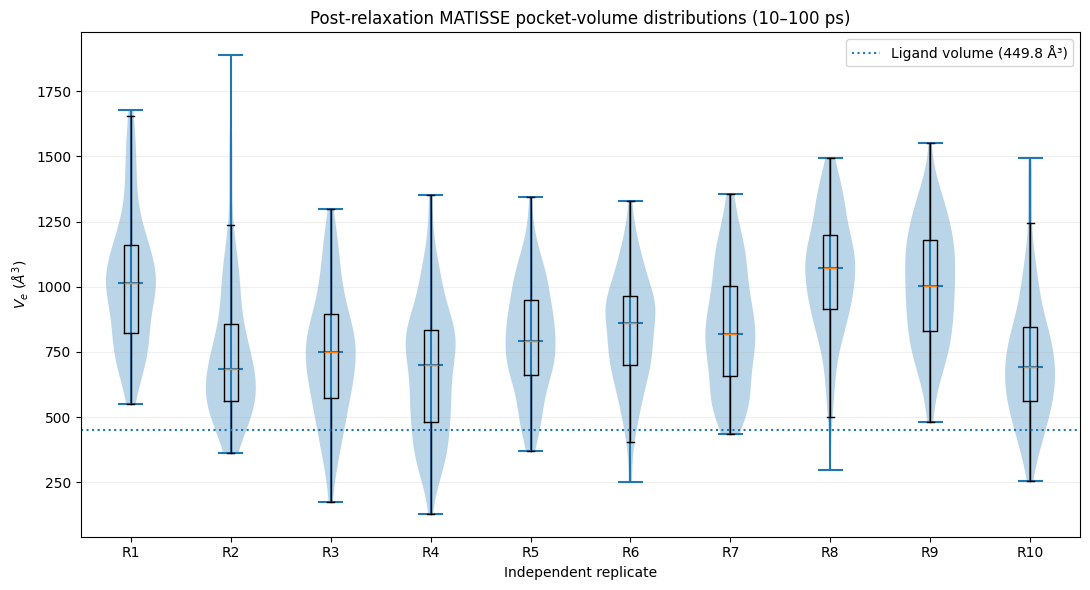

Saved: MATISSE_analysis_output/Figure_B_Ve_distributions_with_ligand_reference.png


In [20]:

#@title 16. Figure B — post-relaxation Ve distributions

if analysis.empty:
    print("Figure B skipped: no post-relaxation data.")
else:
    reps = sorted(analysis["Rep"].unique())

    datasets = [
        analysis.loc[analysis["Rep"] == rep, "Ve"].dropna().to_numpy()
        for rep in reps
    ]

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.violinplot(
        datasets,
        positions=np.arange(1, len(reps) + 1),
        showmeans=False,
        showmedians=True,
        showextrema=True
    )

    ax.boxplot(
        datasets,
        positions=np.arange(1, len(reps) + 1),
        widths=0.14,
        showfliers=False
    )

    ax.axhline(
        ligand_volume_A3,
        linestyle=":",
        linewidth=1.5,
        label=f"Ligand volume ({ligand_volume_A3:.1f} Å³)"
    )

    ax.set_xticks(np.arange(1, len(reps) + 1))
    ax.set_xticklabels([f"R{rep}" for rep in reps])
    ax.set_xlabel("Independent replicate")
    ax.set_ylabel(r"$V_e$ ($\AA^3$)")
    ax.set_title(
        f"Post-relaxation MATISSE pocket-volume distributions "
        f"({RELAX_END_PS:g}–{ANALYSIS_END_PS:g} ps)"
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()

    figB = outdir / "Figure_B_Ve_distributions_with_ligand_reference.png"
    fig.savefig(figB, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    print("Saved:", figB)


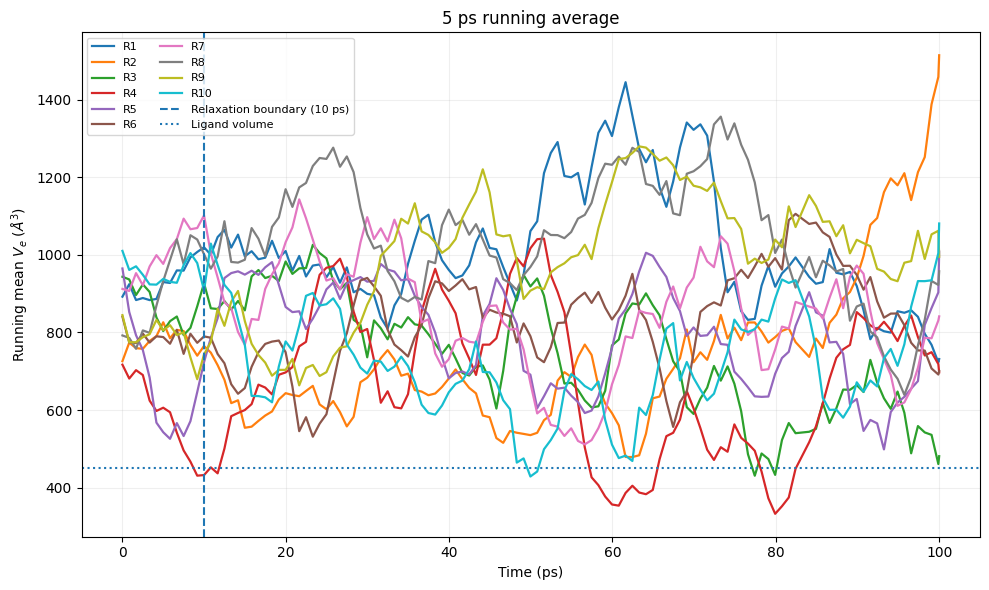

Saved: MATISSE_analysis_output/Figure_C_Ve_running_average.png


In [21]:

#@title 17. Figure C — 5 ps running averages

if not raw_with_runavg["Ve_runavg"].notna().any():
    print("Figure C skipped: running averages are unavailable.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    for rep, grp in raw_with_runavg.groupby("Rep"):
        ax.plot(
            grp["Time_ps"],
            grp["Ve_runavg"],
            linewidth=1.6,
            label=f"R{rep}"
        )

    if raw["Time_ps"].max() >= RELAX_END_PS:
        ax.axvline(
            RELAX_END_PS,
            linestyle="--",
            linewidth=1.5,
            label=f"Relaxation boundary ({RELAX_END_PS:g} ps)"
        )

    ax.axhline(
        ligand_volume_A3,
        linestyle=":",
        linewidth=1.5,
        label="Ligand volume"
    )

    ax.set_xlabel("Time (ps)")
    ax.set_ylabel(r"Running mean $V_e$ ($\AA^3$)")
    ax.set_title(f"{RUNNING_AVG_PS:g} ps running average")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(alpha=0.2)
    fig.tight_layout()

    figC = outdir / "Figure_C_Ve_running_average.png"
    fig.savefig(figC, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    print("Saved:", figC)


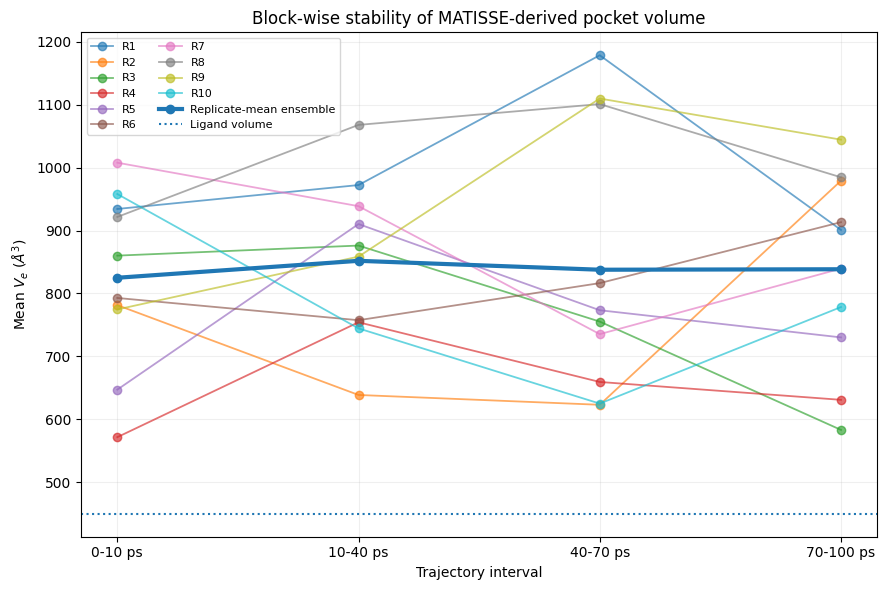

Saved: MATISSE_analysis_output/Figure_D_Ve_block_means.png


In [22]:

#@title 18. Figure D — block-wise mean Ve

if block_stats.empty:
    print("Figure D skipped: block statistics are unavailable.")
else:
    fig, ax = plt.subplots(figsize=(9, 6))

    block_order = (
        block_stats[["Block", "Start_ps"]]
        .drop_duplicates()
        .sort_values("Start_ps")
    )

    ordered_labels = block_order["Block"].tolist()
    x = np.arange(len(ordered_labels))

    for rep in sorted(block_stats["Rep"].unique()):
        temp = (
            block_stats[block_stats["Rep"] == rep]
            .set_index("Block")
            .reindex(ordered_labels)
        )

        ax.plot(
            x,
            temp["meanVe"],
            marker="o",
            linewidth=1.3,
            alpha=0.65,
            label=f"R{rep}"
        )

    ensemble_blocks = (
        block_stats.groupby(["Block", "Start_ps"])["meanVe"]
        .mean()
        .reset_index()
        .sort_values("Start_ps")
        .set_index("Block")
        .reindex(ordered_labels)
    )

    ax.plot(
        x,
        ensemble_blocks["meanVe"],
        marker="o",
        linewidth=3,
        label="Replicate-mean ensemble"
    )

    ax.axhline(
        ligand_volume_A3,
        linestyle=":",
        linewidth=1.5,
        label="Ligand volume"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(ordered_labels)
    ax.set_xlabel("Trajectory interval")
    ax.set_ylabel(r"Mean $V_e$ ($\AA^3$)")
    ax.set_title("Block-wise stability of MATISSE-derived pocket volume")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(alpha=0.2)
    fig.tight_layout()

    figD = outdir / "Figure_D_Ve_block_means.png"
    fig.savefig(figD, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    print("Saved:", figD)


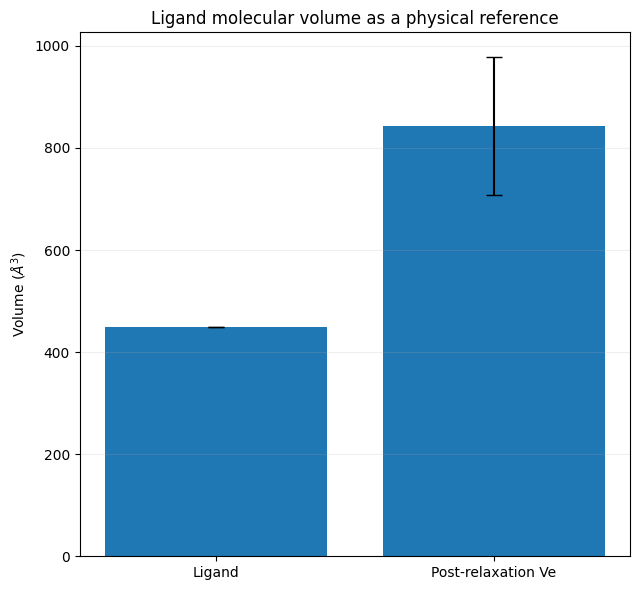

Saved: MATISSE_analysis_output/Figure_E_ligand_vs_postrelaxation_Ve.png


In [23]:

#@title 19. Figure E — ligand volume versus post-relaxation Ve

if np.isnan(combined_mean_Ve):
    print("Figure E skipped: combined post-relaxation Ve is unavailable.")
else:
    labels = ["Ligand", "Post-relaxation Ve"]
    values = [ligand_volume_A3, combined_mean_Ve]
    errors = [0.0, combined_sd_Ve]

    fig, ax = plt.subplots(figsize=(6.5, 6))

    ax.bar(labels, values, yerr=errors, capsize=6)

    ax.set_ylabel(r"Volume ($\AA^3$)")
    ax.set_title("Ligand molecular volume as a physical reference")
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()

    figE = outdir / "Figure_E_ligand_vs_postrelaxation_Ve.png"
    fig.savefig(figE, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    print("Saved:", figE)


In [24]:

#@title 20. Export all numerical tables

raw.to_csv(outdir / "raw_normalized.csv", index=False)
raw_with_runavg.to_csv(outdir / "raw_with_running_average.csv", index=False)
sampling_diagnostics.to_csv(outdir / "sampling_diagnostics.csv", index=False)

whole_summary.to_csv(
    outdir / "whole_trajectory_recalculated_summary.csv",
    index=False
)

macro_check.to_csv(
    outdir / "macro_vs_recalculated_summary.csv",
    index=False
)

per_rep.to_csv(
    outdir / "post_relaxation_per_replicate_statistics.csv",
    index=False
)

combined.to_csv(
    outdir / "combined_replicate_statistics.csv",
    index=False
)

block_stats.to_csv(
    outdir / "block_statistics_per_replicate.csv",
    index=False
)

block_across_reps.to_csv(
    outdir / "block_statistics_across_replicates.csv",
    index=False
)

ligand_info.to_csv(
    outdir / "ligand_volume_information.csv",
    index=False
)

ligand_volume_sensitivity.to_csv(
    outdir / "ligand_volume_grid_sensitivity.csv",
    index=False
)

ligand_comparison.to_csv(
    outdir / "ligand_vs_pocket_volume_comparison.csv",
    index=False
)

print("Exported CSV files:")
for p in sorted(outdir.glob("*.csv")):
    print(" -", p.name)


Exported CSV files:
 - block_statistics_across_replicates.csv
 - block_statistics_per_replicate.csv
 - combined_replicate_statistics.csv
 - ligand_volume_grid_sensitivity.csv
 - ligand_volume_information.csv
 - ligand_vs_pocket_volume_comparison.csv
 - macro_vs_recalculated_summary.csv
 - post_relaxation_per_replicate_statistics.csv
 - raw_normalized.csv
 - raw_with_running_average.csv
 - sampling_diagnostics.csv
 - whole_trajectory_recalculated_summary.csv


In [25]:

#@title 21. Generate automatic reviewer-oriented analysis report

report = []

report.append("MATISSE 5NF9 100 ps replicate analysis")
report.append("=" * 72)
report.append(f"Raw MATISSE file: {raw_name}")
report.append(f"Macro summary file: {summary_name}")
report.append(f"Ligand structure: {ligand_name}")
report.append(f"Independent replicates: {len(rep_ids)}")
report.append(
    f"Observed trajectory range: "
    f"{raw['Time_ps'].min():.4f}–{raw['Time_ps'].max():.4f} ps"
)
report.append("")
report.append("MATISSE NUMERICAL VALIDATION")
report.append("-" * 72)
report.append(
    f"Maximum |Ve - (V - Vi)| = {max_identity_error:.8f} Å^3"
)

report.append("")
report.append("LIGAND VOLUME REFERENCE")
report.append("-" * 72)
report.append(
    f"Crystallographic ligand volume = {ligand_volume_A3:.3f} Å^3 "
    f"(RDKit grid spacing {LIGAND_GRID_SPACING_A:g} Å)."
)
report.append(hydrogen_note)

if not analysis.empty:
    report.append("")
    report.append("POST-RELAXATION RESULTS")
    report.append("-" * 72)

    for _, r in per_rep.iterrows():
        report.append(
            f"Replicate {int(r['Rep'])}: "
            f"V={r['meanV']:.3f} ± {r['stdV']:.3f} Å^3; "
            f"Vi={r['meanVi']:.3f} ± {r['stdVi']:.3f} Å^3; "
            f"Ve={r['meanVe']:.3f} ± {r['stdVe']:.3f} Å^3; "
            f"median Ve={r['medianVe']:.3f}; "
            f"range={r['minVe']:.3f}–{r['maxVe']:.3f}; "
            f"CV={r['CV_percent']:.2f}%."
        )

        if pd.notna(r["meanVe_0_10ps"]):
            report.append(
                f"  Mean Ve 0–{RELAX_END_PS:g} ps = "
                f"{r['meanVe_0_10ps']:.3f} Å^3; "
                f"mean Ve {RELAX_END_PS:g}–{ANALYSIS_END_PS:g} ps = "
                f"{r['meanVe_10_100ps']:.3f} Å^3; "
                f"change={r['percent_change_early_to_post']:.2f}%."
            )

    report.append("")
    report.append(
        f"Across independent replicate means: "
        f"Ve={combined_mean_Ve:.3f} ± {combined_sd_Ve:.3f} Å^3."
    )
    report.append(
        f"The crystallographic ligand volume ({ligand_volume_A3:.3f} Å^3) "
        f"is used only as a physical size reference and is not expected "
        f"to equal the water-accessible MATISSE pocket volume."
    )

if not block_across_reps.empty:
    report.append("")
    report.append("BLOCK ANALYSIS")
    report.append("-" * 72)

    for r in block_across_reps.itertuples():
        report.append(
            f"{r.Block}: ensemble mean of replicate means = "
            f"{r.mean_of_rep_means:.3f} ± "
            f"{r.SD_between_rep_means:.3f} Å^3 "
            f"(n={int(r.nReplicates)} replicates)."
        )

    if not np.isnan(post_block_range_percent):
        report.append(
            f"Range among post-relaxation ensemble block means = "
            f"{post_block_range:.3f} Å^3 "
            f"({post_block_range_percent:.2f}% of their mean)."
        )

report.append("")
report.append("INTERPRETATION CAUTION")
report.append("-" * 72)
report.append(
    "Do not describe 100 ps as proof of global protein equilibrium. "
    "The analysis supports only short-timescale MATISSE pocket-volume behavior."
)
report.append(
    "Adjacent trajectory frames are temporally correlated; independent replicate "
    "trajectories, rather than individual frames, are the independent units for "
    "replicate-level reproducibility."
)

report_path = outdir / "MATISSE_analysis_report.txt"
report_path.write_text("\n".join(report), encoding="utf-8")

print(report_path.read_text())


MATISSE 5NF9 100 ps replicate analysis
Raw MATISSE file: 5NF9_MATISSE_all_replicates.txt
Macro summary file: 5NF9_MATISSE_summary.txt
Ligand structure: 5nf9_lig.pdb
Independent replicates: 10
Observed trajectory range: 0.0000–100.0000 ps

MATISSE NUMERICAL VALIDATION
------------------------------------------------------------------------
Maximum |Ve - (V - Vi)| = 0.00000000 Å^3

LIGAND VOLUME REFERENCE
------------------------------------------------------------------------
Crystallographic ligand volume = 449.840 Å^3 (RDKit grid spacing 0.2 Å).
Explicit hydrogens present in the input ligand were retained.

POST-RELAXATION RESULTS
------------------------------------------------------------------------
Replicate 1: V=1187.796 ± 302.296 Å^3; Vi=170.500 ± 97.830 Å^3; Ve=1017.296 ± 250.091 Å^3; median Ve=1014.000; range=549.000–1679.000; CV=24.58%.
  Mean Ve 0–10 ps = 934.308 Å^3; mean Ve 10–100 ps = 1017.296 Å^3; change=8.88%.
Replicate 2: V=857.991 ± 307.168 Å^3; Vi=111.019 ± 72.148 Å^

In [26]:

#@title 22. Create ZIP archive and download all results

archive_path = shutil.make_archive(
    "MATISSE_analysis_output",
    "zip",
    root_dir=outdir
)

print("Created:", archive_path)
files.download(archive_path)


Created: /content/MATISSE_analysis_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Recommended reporting logic

The ligand volume is a **reference**, not a target value for \(V_e\).

A scientifically defensible interpretation should distinguish:

1. **Within-trajectory fluctuations** — represented by each replicate's `stdVe` and CV.
2. **Between-replicate reproducibility** — represented by the SD among replicate mean \(V_e\) values.
3. **Time-dependent drift** — assessed through the 10–40, 40–70 and 70–100 ps block means and the running-average curves.
4. **Physical size reference** — provided by the crystallographic ligand volume.

Do not call the ligand-volume / pocket-volume ratio a true binding-site occupancy. It is only a geometric size comparison.
